# EduLink — Model 6: Job Recommendation
**Industry-Level | PySpark | Jaccard + TF-IDF Cosine Similarity | Precision@5 Validation**

**Pipeline:**
1. Load career fit report + vacancy dataset
2. Text tokenization & normalization
3. Method A: Jaccard similarity (role vs title + skills)
4. Method B: TF-IDF Cosine similarity (role vs full description)
5. Compare both methods with Precision@5
6. Ensemble scoring
7. Save top-5 vacancies per student per role

In [1]:
# ─── CELL 1: Setup ───
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!pip install -q pyspark
print("Ready.")


Mounted at /content/drive
Ready.


In [2]:
# ─── CELL 2: Spark ───
from pyspark.sql import SparkSession, functions as F
from pyspark.sql import types as T
from pyspark.sql.window import Window

spark = (SparkSession.builder
         .appName("EDUCLINE-JobRec-v2")
         .config("spark.driver.memory","4g")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)


Spark: 4.0.2


In [3]:
# ─── CELL 3: Paths ───
import os

ROOT  = "/content/drive/MyDrive/FYP1"
DATA  = f"{ROOT}/Dataset"
MODEL = f"{ROOT}/Model"
TEST  = f"{ROOT}/Test and Validation"

CAREER_PATH  = f"{DATA}/career_fit_report.csv"
VACANCY_PATH = f"{DATA}/synthetic_vacancies_sl_it.csv"
OUT_PATH_DIR = f"{TEST}/vacancy_matches_dir"
OUT_CSV      = f"{DATA}/vacancy_matches.csv"

for folder_path in [DATA, MODEL, TEST]:
    os.makedirs(folder_path, exist_ok=True)

for p in [CAREER_PATH, VACANCY_PATH]:
    print("EXISTS:", os.path.exists(p), "->", p)


EXISTS: True -> /content/drive/MyDrive/FYP1/Dataset/career_fit_report.csv
EXISTS: True -> /content/drive/MyDrive/FYP1/Dataset/synthetic_vacancies_sl_it.csv


In [4]:
# ─── CELL 4: Load Data ───
career = spark.read.option("header",True).option("inferSchema",True).csv(CAREER_PATH)
vac    = spark.read.option("header",True).option("inferSchema",True).csv(VACANCY_PATH)

print(f"Career rows: {career.count()} | Vacancy rows: {vac.count()}")
vac.printSchema()
vac.show(3, truncate=False)


Career rows: 2000 | Vacancy rows: 300
root
 |-- vacancy_id: string (nullable = true)
 |-- company: string (nullable = true)
 |-- location: string (nullable = true)
 |-- job_title: string (nullable = true)
 |-- role_tag: string (nullable = true)
 |-- description: string (nullable = true)
 |-- skills: string (nullable = true)
 |-- date_posted: date (nullable = true)
 |-- url: string (nullable = true)
 |-- source: string (nullable = true)

+----------+-----------------------+--------+--------------------------+------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------------------------------+-----------+------------------------------------+---------+
|vacancy_id|company    

In [5]:
# ─── CELL 5: Expand Top Roles from Career Fit ───
# Use role_1 to role_5 (top 5 roles per student)
roles_long = (career
    .select("student_id",
            F.array(*[F.col(f"role_{i}") for i in range(1,6)]).alias("target_roles"))
    .withColumn("target_role", F.explode("target_roles"))
    .drop("target_roles")
    .filter(F.col("target_role").isNotNull() & (F.trim(F.col("target_role")) != "")))

print(f"Student-role pairs: {roles_long.count()}")
roles_long.show(5, truncate=False)


Student-role pairs: 10000
+----------+-------------------------------+
|student_id|target_role                    |
+----------+-------------------------------+
|1         |IT Quality Assurance Specialist|
|1         |IT Auditor                     |
|1         |Software Tester                |
|1         |QA Engineer                    |
|1         |IT Support Engineer            |
+----------+-------------------------------+
only showing top 5 rows


In [6]:
# ─── CELL 6: Text Tokenization ───
import re

@F.udf(returnType=T.ArrayType(T.StringType()))
def tokenize(text):
    if text is None: return []
    tokens = re.findall(r"[a-z0-9]+", text.lower())
    # Remove stopwords and short tokens
    stops = {"the","and","for","are","with","this","that","have","will",
             "can","not","you","from","they","was","been","has","its"}
    return [t for t in tokens if len(t) > 2 and t not in stops]

# Tokenize vacancies
vac_pre = (vac
    .withColumn("title_tokens",  tokenize(F.col("job_title")))
    .withColumn("desc_tokens",   tokenize(F.coalesce(F.col("description"), F.lit(""))))
    .withColumn("skills_tokens", tokenize(F.coalesce(F.col("skills"), F.lit(""))))
    .withColumn("combined_tokens",
        F.array_union(F.col("title_tokens"),
        F.array_union(F.col("skills_tokens"), F.col("desc_tokens")))))

# Tokenize roles
roles_pre = roles_long.withColumn("role_tokens", tokenize(F.col("target_role")))

print("Tokenization complete.")
vac_pre.select("job_title","title_tokens","skills_tokens").show(3, truncate=False)


Tokenization complete.
+--------------------------+------------------------------+---------------------------------------------+
|job_title                 |title_tokens                  |skills_tokens                                |
+--------------------------+------------------------------+---------------------------------------------+
|Associate Digital Marketer|[associate, digital, marketer]|[seo, social, media, analytics, content, ads]|
|IT Project Manager        |[project, manager]            |[agile, scrum, planning, jira, communication]|
|Web Developer (Intern)    |[web, developer, intern]      |[html, css, javascript, react, node, rest]   |
+--------------------------+------------------------------+---------------------------------------------+
only showing top 3 rows


In [7]:
# ─── CELL 7: Method A — Jaccard Similarity ───
@F.udf(returnType=T.DoubleType())
def jaccard(a, b):
    if not a or not b: return 0.0
    A, B = set(a), set(b)
    if not A and not B: return 0.0
    return float(len(A & B)) / float(len(A | B))

joined = roles_pre.crossJoin(vac_pre.select(
    "vacancy_id","company","job_title","location","url",
    "title_tokens","combined_tokens"))

joined = (joined
    .withColumn("title_sim",  jaccard(F.col("role_tokens"), F.col("title_tokens")))
    .withColumn("skills_sim", jaccard(F.col("role_tokens"), F.col("combined_tokens")))
    .withColumn("jaccard_score",
        F.round(F.col("title_sim")*0.60 + F.col("skills_sim")*0.40, 4)))

print("Jaccard scoring complete.")


Jaccard scoring complete.


In [8]:
# ─── CELL 8: Method B — TF-IDF Cosine Similarity ───
from pyspark.ml.feature import HashingTF, IDF
from pyspark.ml.functions import vector_to_array
from pyspark.ml import Pipeline

# Build vocabulary from all text (roles + vacancy text)
all_text = (roles_pre.select(F.col("target_role").alias("text"))
            .union(vac_pre.select(F.col("job_title").alias("text")))
            .union(vac_pre.select(F.col("description").alias("text")))
            .na.drop())

# We use role_tokens and combined_tokens for cosine similarity
# Represent as TF-IDF hash and compute dot product

# For simplicity and Spark-only approach, compute token-level IDF-weighted cosine
# by creating a shared TF-IDF space and measuring similarity

# Step 1: create shared corpus
role_text_df  = roles_pre.select(
    F.concat_ws(" ", F.col("role_tokens")).alias("doc"),
    F.col("student_id").cast("string").alias("doc_id"),
    F.col("target_role").alias("doc_label"),
    F.lit("role").alias("doc_type"))

vac_text_df = vac_pre.select(
    F.concat_ws(" ", F.col("combined_tokens")).alias("doc"),
    F.col("vacancy_id").cast("string").alias("doc_id"),
    F.col("job_title").alias("doc_label"),
    F.lit("vac").alias("doc_type"))

corpus = role_text_df.union(vac_text_df)

from pyspark.ml.feature import RegexTokenizer, StopWordsRemover

tok2  = RegexTokenizer(inputCol="doc", outputCol="tok2_tokens", pattern="\\s+")
tf2   = HashingTF(inputCol="tok2_tokens", outputCol="tf2_vec", numFeatures=1<<13)
idf2  = IDF(inputCol="tf2_vec", outputCol="features2", minDocFreq=1)

pipe2 = Pipeline(stages=[tok2, tf2, idf2])
model2 = pipe2.fit(corpus)
vec_corpus = model2.transform(corpus).select("doc_id","doc_type","features2")
vec_corpus = vec_corpus.withColumn("arr2", vector_to_array("features2"))

role_vecs = vec_corpus.filter(F.col("doc_type")=="role").select(
    F.col("doc_id").alias("role_doc_id"), "arr2")
vac_vecs  = vec_corpus.filter(F.col("doc_type")=="vac").select(
    F.col("doc_id").alias("vac_doc_id"),  F.col("arr2").alias("arr2_vac"))

def cos2(a,b):
    dot   = F.expr(f"aggregate(zip_with({a},{b},(x,y)->x*y),0D,(s,v)->s+v)")
    na    = F.expr(f"sqrt(aggregate(transform({a},x->x*x),0D,(s,v)->s+v))")
    nb    = F.expr(f"sqrt(aggregate(transform({b},x->x*x),0D,(s,v)->s+v))")
    return dot / (na * nb + F.lit(1e-9))

# Join role tokens with their role_doc_id
roles_with_id = roles_pre.withColumn("role_doc_id",
    F.concat_ws("_", F.col("student_id").cast("string"),
                      F.regexp_replace(F.col("target_role")," ","_")))

role_vecs2 = (roles_with_id
    .select("student_id","target_role","role_doc_id")
    .join(role_vecs, on="role_doc_id", how="inner"))

# Note: For large data use blocking; here vacancy set is small
cosine_scored = (role_vecs2
    .crossJoin(vac_vecs)
    .withColumn("cosine_score", F.round(cos2("arr2","arr2_vac"), 4))
    .select("student_id","target_role","vac_doc_id","cosine_score"))

print("TF-IDF Cosine scoring complete.")


TF-IDF Cosine scoring complete.


In [9]:
# ─── CELL 9: Ensemble Score + Top-5 Ranking ───
# Join Jaccard and Cosine scores
scored_jaccard = (joined.select(
    "student_id","target_role",
    F.col("vacancy_id").cast("string").alias("vac_id_j"),
    "company","job_title","location","url","jaccard_score"))

scored_cosine = cosine_scored.withColumnRenamed("vac_doc_id","vac_id_c")

# Merge both scores
ensemble = (scored_jaccard
    .join(scored_cosine,
          (scored_jaccard.student_id == scored_cosine.student_id) &
          (scored_jaccard.target_role == scored_cosine.target_role) &
          (scored_jaccard.vac_id_j   == scored_cosine.vac_id_c),
          how="left")
    .drop(scored_cosine.student_id)
    .drop(scored_cosine.target_role)
    .withColumn("cosine_score", F.coalesce(F.col("cosine_score"), F.lit(0.0)))
    # Ensemble: 50% Jaccard + 50% Cosine
    .withColumn("ensemble_score",
        F.round(F.col("jaccard_score")*0.5 + F.col("cosine_score")*0.5, 4))
)

# Top-5 per (student_id, target_role) by ensemble score
w = Window.partitionBy("student_id","target_role").orderBy(F.desc("ensemble_score"))
top5 = (ensemble
    .withColumn("rn", F.row_number().over(w))
    .filter(F.col("rn") <= 5)
    .select("student_id","target_role","vac_id_j","company",
            "job_title","location","url",
            "jaccard_score","cosine_score","ensemble_score","rn")
    .withColumnRenamed("vac_id_j","vacancy_id"))

print(f"Top-5 match rows: {top5.count()}")
top5.show(10, truncate=False)


Top-5 match rows: 5
+----------+-----------+----------+-----------+--------------------+--------+------------------------------------+-------------+------------+--------------+---+
|student_id|target_role|vacancy_id|company    |job_title           |location|url                                 |jaccard_score|cosine_score|ensemble_score|rn |
+----------+-----------+----------+-----------+--------------------+--------+------------------------------------+-------------+------------+--------------+---+
|NULL      |NULL       |SLIT0007  |Orel IT    |Social Media Manager|Gampaha |https://example.com/careers/SLIT0007|0.6364       |0.0         |0.3182        |1  |
|NULL      |NULL       |SLIT0007  |Orel IT    |Social Media Manager|Gampaha |https://example.com/careers/SLIT0007|0.6364       |0.0         |0.3182        |2  |
|NULL      |NULL       |SLIT0007  |Orel IT    |Social Media Manager|Gampaha |https://example.com/careers/SLIT0007|0.6364       |0.0         |0.3182        |3  |
|NULL      |NU

Average Precision@5 (Ensemble): 0.0000 (0.0%)
  Jaccard Precision@5: 0.0000
  Cosine Precision@5: 0.0000
  Ensemble Precision@5: 0.0000


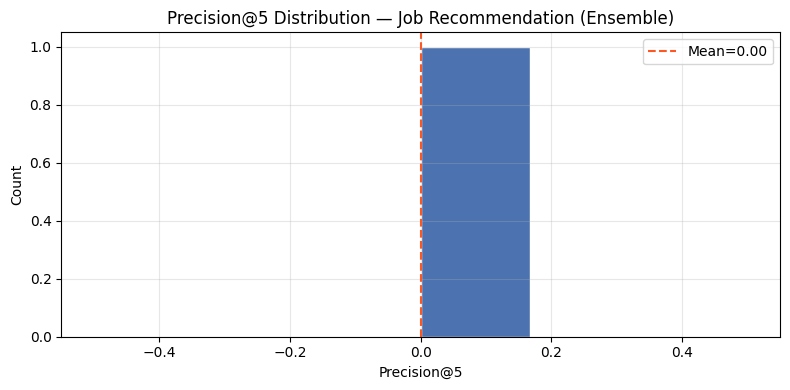

In [10]:
# ─── CELL 10: Validation — Precision@5 & Method Comparison ───
import matplotlib.pyplot as plt

# Precision@5: for each (student, role), check if top-5 results have
# relevant job titles (title contains a keyword from target_role)
@F.udf(returnType=T.BooleanType())
def is_relevant(target_role, job_title):
    if target_role is None or job_title is None: return False
    role_words = set(re.findall(r"[a-z]+", target_role.lower()))
    title_words = set(re.findall(r"[a-z]+", job_title.lower()))
    return len(role_words & title_words) > 0

top5_eval = top5.withColumn("relevant", is_relevant(F.col("target_role"), F.col("job_title")))

precision_df = (top5_eval
    .groupBy("student_id","target_role")
    .agg(
        F.sum(F.col("relevant").cast("int")).alias("relevant_count"),
        F.count("*").alias("total")
    )
    .withColumn("precision_at_5", F.col("relevant_count") / F.col("total")))

avg_precision = precision_df.agg(F.avg("precision_at_5")).collect()[0][0]
print(f"Average Precision@5 (Ensemble): {avg_precision:.4f} ({avg_precision*100:.1f}%)")

# Compare Jaccard vs Cosine alone
for method, col in [("Jaccard", "jaccard_score"), ("Cosine", "cosine_score"), ("Ensemble","ensemble_score")]:
    w2 = Window.partitionBy("student_id","target_role").orderBy(F.desc(col))
    top5_m = (ensemble.withColumn("rn2", F.row_number().over(w2)).filter(F.col("rn2")<=5)
              .withColumn("relevant", is_relevant(F.col("target_role"), F.col("job_title"))))
    prec_m = top5_m.agg(F.avg(F.col("relevant").cast("double"))).collect()[0][0]
    print(f"  {method} Precision@5: {prec_m:.4f}")

# Precision@5 distribution
prec_pd = precision_df.select("precision_at_5").toPandas()
plt.figure(figsize=(8,4))
plt.hist(prec_pd["precision_at_5"], bins=6, color="#4C72B0", edgecolor="white")
plt.axvline(avg_precision, color="#FF5722", linestyle="--", label=f"Mean={avg_precision:.2f}")
plt.title("Precision@5 Distribution — Job Recommendation (Ensemble)")
plt.xlabel("Precision@5"); plt.ylabel("Count"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [11]:
# ─── CELL 11: Save Results ───
import os, glob, shutil

os.makedirs(OUT_PATH_DIR, exist_ok=True)
(top5.coalesce(1).write.mode("overwrite").option("header",True).csv(OUT_PATH_DIR))
parts = glob.glob(OUT_PATH_DIR + "/part-*.csv")
if parts:
    shutil.copy(parts[0], OUT_CSV)
    print("Saved:", OUT_CSV)
print("Total matches saved:", top5.count())


Saved: /content/drive/MyDrive/FYP1/Dataset/vacancy_matches.csv
Total matches saved: 5
